## Dependencies

In [ ]:
## libraries
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.evaluators.config import FEAT_X, FEAT_Z, TARGET
from src.data.helpers import load_processed_data
from src.evaluators.helpers import load_models
from src.evaluators.perturbing import eval_perturb
from src.data.helpers import load_perturbed_data

/Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initalization

In [2]:
## setup
data = load_processed_data()
models = load_models()
data_pert = load_perturbed_data()

## Training

In [3]:
## perturbation evaluation (retrain + frozen logo-cv)
results_data, perturbed_all, recovery_df = eval_perturb(
    data = data,
    models = models,
    data_pert = data_pert,
    feat_x = FEAT_X,
    feat_z = FEAT_Z,
    target = TARGET,
)

Running 756 perturbation jobs in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
/Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   16.5s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   23.3s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   30.8s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   34.4s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   43.1s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   48.5s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:  

Done. 756 / 756 jobs succeeded.


## Manuscript Table

In [4]:
## display settings
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

## column name lists
FEAT_FRONTIER = ["vr", "mv", "ms", "ea", "ei"]
FEAT_DELTA = [f"d_{c}" for c in FEAT_FRONTIER]

## table 1: frozen-track perturbation deltas (stability)
frozen = perturbed_all.query("track == 'frozen'")
frozen_tbl = frozen.groupby("perturbation")[FEAT_DELTA].mean().round(4)
print("=== Table 1: Frozen-Track Perturbation Deltas (Δ_frozen) ===")
display(frozen_tbl)

## table 2: retrain-track perturbation deltas (recoverability)
retrain = perturbed_all.query("track == 'retrain'")
retrain_tbl = retrain.groupby("perturbation")[FEAT_DELTA].mean().round(4)
print("\n=== Table 2: Retrain-Track Perturbation Deltas (Δ_retrain) ===")
display(retrain_tbl)

## table 3: recovery ratios
FEAT_RHO_DISPLAY = [f"rho_{c}" for c in FEAT_FRONTIER]
recovery_tbl = recovery_df.groupby("perturbation")[FEAT_RHO_DISPLAY].mean().round(4)
print("\n=== Table 3: Recovery Ratios (ρ) ===")
display(recovery_tbl)

=== Table 1: Frozen-Track Perturbation Deltas (Δ_frozen) ===


,d_vr,d_mv,d_ms,d_ea,d_ei
perturbation,,,,,
invariants,0.018200,-3.385500,-0.099500,0.003300,-0.001700
network,0.027900,-3.129300,-0.041100,0.017300,0.012600
process,0.013100,-3.413400,1230.494300,125.051400,0.006900
signature,0.014000,-3.386900,-0.002200,0.022400,-0.001500



=== Table 2: Retrain-Track Perturbation Deltas (Δ_retrain) ===


,d_vr,d_mv,d_ms,d_ea,d_ei
perturbation,,,,,
invariants,0.019400,-1.919400,3.182500,0.447700,0.019300
network,0.043900,93839.686100,19187199.683900,1946012.256700,0.039400
process,0.009700,-3.275500,0.881600,0.130200,0.006000
signature,0.022200,-3.156700,-0.295500,-0.001300,0.007300



=== Table 3: Recovery Ratios (ρ) ===


,rho_vr,rho_mv,rho_ms,rho_ea,rho_ei
perturbation,,,,,
invariants,0.509400,2.377200,-53.454100,-10.889900,0.596200
network,0.660200,2.199000,-161637149.741600,-29886600.433600,0.554800
process,0.396000,0.267000,0.770400,0.024000,0.450300
signature,0.105300,-2.041300,2.192900,-0.246100,0.318500


In [5]:
## baseline lookup for diagnostics
baseline_lookup = (
    results_data.query("perturbation == 'baseline'")
    .drop_duplicates(subset = ["model"])
    .set_index("model")[FEAT_FRONTIER]
)

## 1) sample sizes used in table aggregation
n_tbl = (
    perturbed_all.groupby(["track", "perturbation"])["model"]
    .count()
    .rename("n_rows")
    .reset_index()
)
display(n_tbl.sort_values(["track", "n_rows"]))

## 2) relative delta vs baseline magnitude
rel = perturbed_all.copy()
for m in FEAT_FRONTIER:
    base = rel["model"].map(baseline_lookup[m]).abs().clip(lower = 1e-9)
    rel[f"rd_{m}"] = rel[f"d_{m}"] / base

rel_tbl = rel.groupby(["track", "perturbation"])[[f"rd_{m}" for m in FEAT_FRONTIER]].mean()
display(rel_tbl.round(4))

## 3) method-level process breakdown
proc_tbl = (
    perturbed_all.query("perturbation == 'process'")
    .groupby(["track", "method"])[FEAT_DELTA]
    .agg(["mean", "std", "count"])
)
display(proc_tbl.round(4))

,track,perturbation,n_rows
0,frozen,invariants,189
1,frozen,network,189
2,frozen,process,189
3,frozen,signature,189
4,retrain,invariants,189
5,retrain,network,189
6,retrain,process,189
7,retrain,signature,189


rd_vr           rd_mv          rd_ms  \
track   perturbation                                                 
frozen  invariants   1904762.106500  8636575.246000      -0.027000   
        network      2539682.850500 13802260.829100      -0.016200   
        process      4338624.515900 22521343.403300     147.344400   
        signature    4021164.129000 22292534.716200      -0.010000   
retrain invariants   4232804.306900 18364569.945800       0.343900   
        network      3174603.594600 12289453.196000 2022940.193900   
        process      4232804.291300 18497327.062100       0.118700   
        signature    6349206.511900 28661928.848700      -0.031600   

                              rd_ea     rd_ei  
track   perturbation                           
frozen  invariants        -0.003000 -0.006500  
        network            0.012900  0.012700  
        process           91.677600  0.005800  
        signature          0.017100 -0.006500  
retrain invariants         0.321300  0.029800  
        network      1307607.869900  0.064200  
        process            0.120200  0.005500  
        signature          0.014100  0.008000

d_vr                     d_mv                 \
                           mean      std count      mean      std count   
track   method                                                            
frozen  bootstrapping  0.044600 0.060700    63 -3.353200 9.600200    63   
        scaling        0.019200 0.077300    63 -3.361600 9.638000    63   
        smoothing     -0.024400 0.061100    63 -3.525400 9.658400    63   
retrain bootstrapping -0.006200 0.048900    63 -3.317500 9.295800    63   
        scaling        0.013500 0.058100    63 -3.231600 9.286200    63   
        smoothing      0.021900 0.062600    63 -3.277200 9.486300    63   

                             d_ms                          d_ea              \
                             mean          std count       mean         std   
track   method                                                                
frozen  bootstrapping   -0.462400     0.443500    63  -0.044500    0.072900   
        scaling       3691.399200 20165.887700    63 375.074300 2048.677000   
        smoothing        0.546000     0.894700    63   0.124300    0.154000   
retrain bootstrapping    0.116100     0.983300    63   0.060600    0.150800   
        scaling          1.967100     9.335400    63   0.226500    0.952900   
        smoothing        0.561700     1.142200    63   0.103400    0.130400   

                                 d_ei                 
                      count      mean      std count  
track   method                                        
frozen  bootstrapping    63  0.005500 0.046500    63  
        scaling          63  0.032700 0.091100    63  
        smoothing        63 -0.017600 0.060900    63  
retrain bootstrapping    63 -0.006400 0.046700    63  
        scaling          63  0.009900 0.054000    63  
        smoothing        63  0.014300 0.051600    63

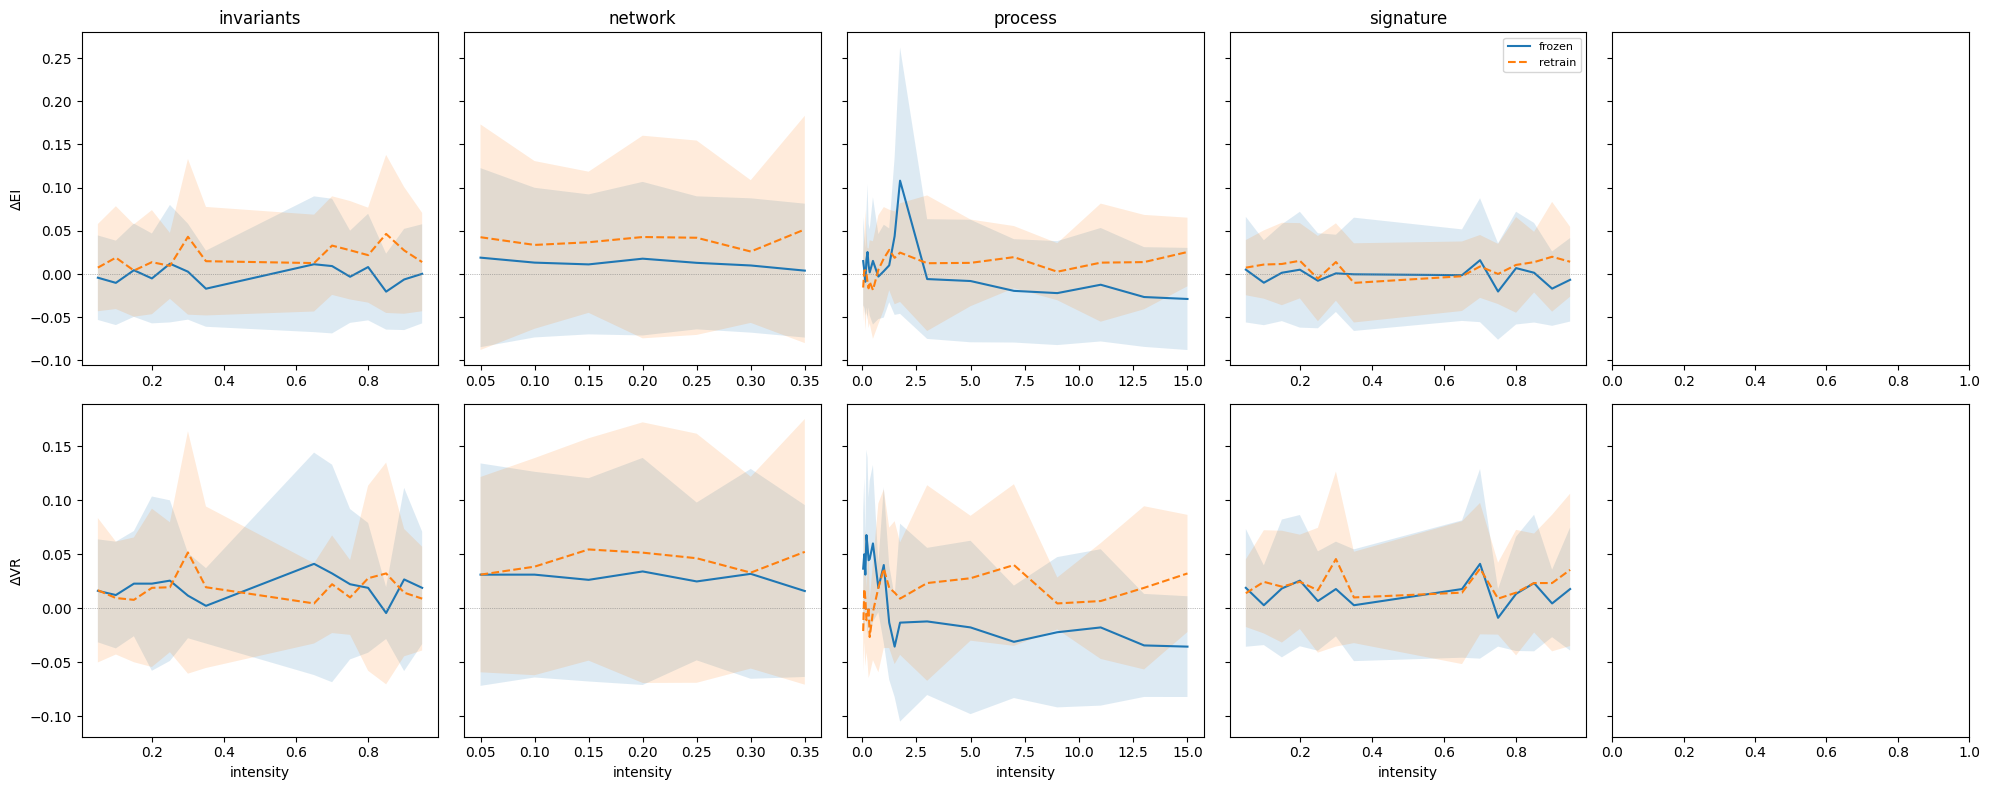

In [6]:
import matplotlib.pyplot as plt

## intensity-response curves: ΔEI and ΔVR by perturbation family
fig, axes = plt.subplots(2, 5, figsize = (20, 8), sharey = "row")
families = sorted(perturbed_all["perturbation"].unique())

for j, family in enumerate(families):
    subset = perturbed_all[perturbed_all["perturbation"] == family].copy()

    ## temporal uses aggregation windows (e.g. "2W"), extract numeric part
    if family == "temporal":
        subset["_x"] = subset["intensity"].str.extract(r"(\d+)").astype(float)
        x_label = "window (weeks)"
    else:
        subset["_x"] = pd.to_numeric(subset["intensity"], errors = "coerce")
        x_label = "intensity"
    subset = subset.dropna(subset = ["_x"])

    for i, (metric, label) in enumerate([("d_ei", "ΔEI"), ("d_vr", "ΔVR")]):
        ax = axes[i, j]
        for track, style in [("frozen", "-"), ("retrain", "--")]:
            grp = subset[subset["track"] == track].groupby("_x")[metric].agg(["mean", "std"]).reset_index()
            ax.plot(grp["_x"], grp["mean"], style, label = track)
            ax.fill_between(grp["_x"], grp["mean"] - grp["std"], grp["mean"] + grp["std"], alpha = 0.15)
        ax.axhline(0, color = "gray", linewidth = 0.5, linestyle = ":")
        if i == 0:
            ax.set_title(family)
        if j == 0:
            ax.set_ylabel(label)
        if i == 1:
            ax.set_xlabel(x_label)
        if i == 0 and j == len(families) - 1:
            ax.legend(fontsize = 8)

plt.tight_layout()
plt.show()

In [7]:
## count raw perturbation settings by family
raw_settings = []
for json_key, methods in data_pert.items():
    for method, intensities in methods.items():
        for intensity, pert_df in intensities.items():
            raw_settings.append({
                "json_key": json_key,
                "method": method,
                "intensity": intensity,
                "n_datasets": len(pert_df),
            })

raw_settings = pd.DataFrame(raw_settings)
display(raw_settings.groupby("json_key").agg(
    n_methods = ("method", "nunique"),
    n_intensities = ("intensity", "nunique"),
    n_settings = ("intensity", "size"),
    mean_datasets = ("n_datasets", "mean"),
).sort_index())

display(raw_settings.sort_values(["json_key", "method", "intensity"]))

,n_methods,n_intensities,n_settings,mean_datasets
json_key,,,,
invariants_perturbed,3,14,21,24.000000
network_perturbed,3,7,21,24.000000
process_perturbed,3,20,21,24.000000
signatures_perturbed,3,14,21,24.000000


,json_key,method,intensity,n_datasets
0,invariants_perturbed,jitter,0.050000,24
1,invariants_perturbed,jitter,0.100000,24
2,invariants_perturbed,jitter,0.150000,24
3,invariants_perturbed,jitter,0.200000,24
4,invariants_perturbed,jitter,0.250000,24
5,invariants_perturbed,jitter,0.300000,24
6,invariants_perturbed,jitter,0.350000,24
7,invariants_perturbed,noise,0.050000,24
8,invariants_perturbed,noise,0.100000,24
9,invariants_perturbed,noise,0.150000,24


In [8]:
## Statistical Significance Testing

from scipy import stats

# helpers

def ci_mean(series, confidence=0.95):
    arr = series.dropna().to_numpy()
    n = len(arr)
    if n < 2:
        return (np.nan, np.nan)
    m = arr.mean()
    se = stats.sem(arr)
    h = se * stats.t.ppf((1 + confidence) / 2.0, n - 1)
    return (m - h, m + h)


signif_rows = []
for perturbation, grp in perturbed_all.groupby("perturbation"):
    for track in ["frozen", "retrain"]:
        sub = grp[grp["track"] == track]
        if sub.empty:
            continue
        for m in FEAT_DELTA:
            values = sub[m].dropna()
            if len(values) < 2:
                continue
            mean = values.mean()
            ci_lo, ci_hi = ci_mean(values)
            tstat, pval = stats.ttest_1samp(values, 0.0, nan_policy="omit")
            signif_rows.append({
                "perturbation": perturbation,
                "track": track,
                "metric": m,
                "n": len(values),
                "mean": mean,
                "ci_lo": ci_lo,
                "ci_hi": ci_hi,
                "p_value": pval,
            })


signif_df = pd.DataFrame(signif_rows)
signif_df["p_value"] = signif_df["p_value"].round(6)

print("=== Statistical significance (mean Δ vs 0) for each perturbation × track ===")
display(
    signif_df.sort_values(["perturbation", "track", "metric"]).reset_index(drop=True)
)

# compare frozen vs retrain (independent t-test) for each perturbation and metric
comp_rows = []
for perturbation, grp in perturbed_all.groupby("perturbation"):
    fr = grp[grp["track"] == "frozen"]
    rt = grp[grp["track"] == "retrain"]
    if fr.empty or rt.empty:
        continue
    for m in FEAT_DELTA:
        a = fr[m].dropna()
        b = rt[m].dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        tstat, pval = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        comp_rows.append({
            "perturbation": perturbation,
            "metric": m,
            "n_frozen": len(a),
            "n_retrain": len(b),
            "p_value": pval,
            "frozen_mean": a.mean(),
            "retrain_mean": b.mean(),
        })

comp_df = pd.DataFrame(comp_rows)
comp_df["p_value"] = comp_df["p_value"].round(6)

print("\n=== Frozen vs Retrain (independent t-test) ===")
display(comp_df.sort_values(["perturbation", "metric"]))


=== Statistical significance (mean Δ vs 0) for each perturbation × track ===


,perturbation,track,metric,n,mean,ci_lo,ci_hi,p_value
0,invariants,frozen,d_ea,189,0.003283,-0.006721,0.013287,0.518166
1,invariants,frozen,d_ei,189,-0.001702,-0.009664,0.006260,0.673667
2,invariants,frozen,d_ms,189,-0.099529,-0.154172,-0.044886,0.000417
3,invariants,frozen,d_mv,189,-3.385483,-4.767673,-2.003293,0.000003
4,invariants,frozen,d_vr,189,0.018201,0.009384,0.027018,0.000069
5,invariants,retrain,d_ea,189,0.447739,0.200670,0.694808,0.000445
6,invariants,retrain,d_ei,189,0.019338,0.010513,0.028163,0.000025
7,invariants,retrain,d_ms,189,3.182528,1.227209,5.137846,0.001557
8,invariants,retrain,d_mv,189,-1.919431,-3.355539,-0.483324,0.009075
9,invariants,retrain,d_vr,189,0.019365,0.009453,0.029277,0.000159



=== Frozen vs Retrain (independent t-test) ===


,perturbation,metric,n_frozen,n_retrain,p_value,frozen_mean,retrain_mean
3,invariants,d_ea,189,189,0.000494,0.003283,0.447739
4,invariants,d_ei,189,189,0.000537,-0.001702,0.019338
2,invariants,d_ms,189,189,0.001119,-0.099529,3.182528
1,invariants,d_mv,189,189,0.147630,-3.385483,-1.919431
0,invariants,d_vr,189,189,0.862674,0.018201,0.019365
8,network,d_ea,189,189,0.129367,0.017343,1946012.256673
9,network,d_ei,189,189,0.007293,0.012568,0.039391
7,network,d_ms,189,189,0.129367,-0.041082,19187199.683906
6,network,d_mv,189,189,0.318443,-3.129255,93839.686069
5,network,d_vr,189,189,0.116959,0.027884,0.043862


In [9]:
## Significance summary

# Summarize how many tests are significant (p < 0.05)
summary = []
for df_name, df in [("Δ vs 0", signif_df), ("Frozen vs Retrain", comp_df)]:
    if df.empty:
        summary.append({"table": df_name, "n_tests": 0, "n_sig": 0, "pct_sig": np.nan})
        continue
    n_tests = len(df)
    n_sig = (df["p_value"] < 0.05).sum()
    summary.append({"table": df_name, "n_tests": n_tests, "n_sig": n_sig, "pct_sig": float(n_sig) / n_tests})

summary_df = pd.DataFrame(summary)
print("=== Significance summary ===")
display(summary_df)

print("\n=== Top significant results (Δ vs 0) ===")
display(signif_df.sort_values("p_value").head(10))

print("\n=== Top significant results (Frozen vs Retrain) ===")
display(comp_df.sort_values("p_value").head(10))

=== Significance summary ===


,table,n_tests,n_sig,pct_sig
0,Δ vs 0,40,27,0.675000
1,Frozen vs Retrain,20,5,0.250000



=== Top significant results (Δ vs 0) ===


,perturbation,track,metric,n,mean,ci_lo,ci_hi,p_value
35,signature,retrain,d_vr,189,0.022222,0.014516,0.029929,0.000000
15,network,retrain,d_vr,189,0.043862,0.028736,0.058989,0.000000
19,network,retrain,d_ei,189,0.039391,0.023913,0.054870,0.000001
21,process,frozen,d_mv,189,-3.413386,-4.788191,-2.038580,0.000002
1,invariants,frozen,d_mv,189,-3.385483,-4.767673,-2.003293,0.000003
36,signature,retrain,d_mv,189,-3.156676,-4.455815,-1.857537,0.000003
31,signature,frozen,d_mv,189,-3.386936,-4.768763,-2.005110,0.000003
26,process,retrain,d_mv,189,-3.275458,-4.610881,-1.940035,0.000003
11,network,frozen,d_mv,189,-3.129255,-4.528595,-1.729915,0.000017
9,invariants,retrain,d_ei,189,0.019338,0.010513,0.028163,0.000025



=== Top significant results (Frozen vs Retrain) ===


,perturbation,metric,n_frozen,n_retrain,p_value,frozen_mean,retrain_mean
17,signature,d_ms,189,189,0.000277,-0.002226,-0.295487
3,invariants,d_ea,189,189,0.000494,0.003283,0.447739
4,invariants,d_ei,189,189,0.000537,-0.001702,0.019338
2,invariants,d_ms,189,189,0.001119,-0.099529,3.182528
9,network,d_ei,189,189,0.007293,0.012568,0.039391
18,signature,d_ea,189,189,0.061860,0.022410,-0.001331
19,signature,d_ei,189,189,0.088558,-0.001534,0.007262
5,network,d_vr,189,189,0.116959,0.027884,0.043862
7,network,d_ms,189,189,0.129367,-0.041082,19187199.683906
8,network,d_ea,189,189,0.129367,0.017343,1946012.256673


In [10]:
## Significance summary

# Summarize how many tests are significant (p < 0.05)
summary = []
for df_name, df in [("Δ vs 0", signif_df), ("Frozen vs Retrain", comp_df)]:
    if df.empty:
        summary.append({"table": df_name, "n_tests": 0, "n_sig": 0, "pct_sig": np.nan})
        continue
    n_tests = len(df)
    n_sig = (df["p_value"] < 0.05).sum()
    summary.append({"table": df_name, "n_tests": n_tests, "n_sig": n_sig, "pct_sig": float(n_sig) / n_tests})

summary_df = pd.DataFrame(summary)
print("=== Significance summary ===")
display(summary_df)

print("\n=== Top significant results (Δ vs 0) ===")
display(signif_df.sort_values("p_value").head(10))

print("\n=== Top significant results (Frozen vs Retrain) ===")
display(comp_df.sort_values("p_value").head(10))


=== Significance summary ===


,table,n_tests,n_sig,pct_sig
0,Δ vs 0,40,27,0.675000
1,Frozen vs Retrain,20,5,0.250000



=== Top significant results (Δ vs 0) ===


,perturbation,track,metric,n,mean,ci_lo,ci_hi,p_value
35,signature,retrain,d_vr,189,0.022222,0.014516,0.029929,0.000000
15,network,retrain,d_vr,189,0.043862,0.028736,0.058989,0.000000
19,network,retrain,d_ei,189,0.039391,0.023913,0.054870,0.000001
21,process,frozen,d_mv,189,-3.413386,-4.788191,-2.038580,0.000002
1,invariants,frozen,d_mv,189,-3.385483,-4.767673,-2.003293,0.000003
36,signature,retrain,d_mv,189,-3.156676,-4.455815,-1.857537,0.000003
31,signature,frozen,d_mv,189,-3.386936,-4.768763,-2.005110,0.000003
26,process,retrain,d_mv,189,-3.275458,-4.610881,-1.940035,0.000003
11,network,frozen,d_mv,189,-3.129255,-4.528595,-1.729915,0.000017
9,invariants,retrain,d_ei,189,0.019338,0.010513,0.028163,0.000025



=== Top significant results (Frozen vs Retrain) ===


,perturbation,metric,n_frozen,n_retrain,p_value,frozen_mean,retrain_mean
17,signature,d_ms,189,189,0.000277,-0.002226,-0.295487
3,invariants,d_ea,189,189,0.000494,0.003283,0.447739
4,invariants,d_ei,189,189,0.000537,-0.001702,0.019338
2,invariants,d_ms,189,189,0.001119,-0.099529,3.182528
9,network,d_ei,189,189,0.007293,0.012568,0.039391
18,signature,d_ea,189,189,0.061860,0.022410,-0.001331
19,signature,d_ei,189,189,0.088558,-0.001534,0.007262
5,network,d_vr,189,189,0.116959,0.027884,0.043862
7,network,d_ms,189,189,0.129367,-0.041082,19187199.683906
8,network,d_ea,189,189,0.129367,0.017343,1946012.256673
